# Reinforcement Learning: A **policy-based** simple example 1
Scenario: Agent Navigating a **1D Grid**

A 1D world with 5 positions (AKA **state**): [0]---[1]---[2]---[3]---[4]

- Start at position 0
- Objective: Maximize total reward, i.e. reach position 4 as quickly as possible. 
- Two actions: move right (1) or move left (0)
- Reward: +1 when reaching position 4, 0 otherwise (NOTE: no penalty here)
- Policy: Probability distribution over actions (or it can be a neural network) (here, we use softmax)

 

Here update rule is **"Policy Gradient using REINFORCE algorithm"**

# PSEUDOCODE:

## 1. Define the Environment:

- A class called OneDGridEnv is created to represent a simple one-dimensional grid environment.
- The environment has a size (default is 5) and starts with the agent's position at 0.
- The reset method sets the agent's position back to the start (0).
- The step method takes an action (either move right or left) and updates the agent's position. If the agent reaches the end of the grid, it receives a reward of 1. The method also checks if the episode is done (i.e., if the agent has reached the end).


## 2. Define the Policy Agent:
- Class PolicyAgent is created to represent the agent that will learn to navigate the environment.
- The agent has a policy (a way to decide actions) initialized randomly, a learning rate, and methods to choose actions and update its policy based on experiences.
- The get_action_probs method calculates the probabilities of taking each action based on the current state using a softmax function. **It takes input the state, find its policy(z) and then convert it into probablity using softmax function.**

  Mathematically:
$$
\pi(a, s) = \frac{e^{z_{a, s}}}{\sum_{b, s} e^{z_{b, s}}}
$$
This is the probability of taking action a when present in state s
For example If agent.policy[0] = [0.3745 0.9507] , that is raw policy table for state 0:[0.3745 0.9507]

**Probabilities:**

$$
p(a = 0) = \frac{e^{0.3745}}{e^{0.3745} + e^{0.9507}} \approx 0.356
$$

$$
p(a = 1) = \frac{e^{0.9507}}{e^{0.3745} + e^{0.9507}} \approx 0.644
$$

**So:**
- Action 0(left) has about a 36.0% chance.  
- Action 1(right) has about a 64.0% chance.

The resulting vector `probs` gives the probability of taking each action in that state.  

- The choose_action method selects an action based on these probabilities.
- The update_policy method adjusts the agent's policy based on the actions taken and the rewards received during an episode.

## 3. Training the Agent:
- An instance of the environment and the agent is created.
- The agent is trained over a specified number of episodes (1000 in this case).
- For each episode, the environment is reset, and the agent takes actions until it reaches the end of the grid.
- The actions, states, and rewards are recorded in an episode list.
- After the episode ends, the agent updates its policy based on the recorded experiences.
- The total reward for the episode is calculated and stored.

## 4. Plotting Results:
- Finally, the code plots the total rewards over time, smoothing the results to show the agent's learning progress.

In [1]:
# A note on how to pick random numbers with certain probability distribution 
import numpy as np
for i in range(10):
    print(np.random.choice([0, 1], p=[0.3, 0.7]))

1
1
1
1
1
1
1
0
1
1


In [29]:
# STEP1: create a class for Environment and an Agent
# Here I am not using discounted reward: future rewards are not considered when updating earlier states.
import numpy as np
import matplotlib.pyplot as plt
import random

# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)

# Simple environment
class OneDGridEnv:
    def __init__(self, size=5):
        self.size = size
        self.reset()

    def reset(self):
        self.state = 0 # Here position = state
        return self.state

    def step(self, action):
        
        # Action: 0 = left, 1 = right 
        if action == 1: # that is, go Right
            self.state = min(self.state + 1, self.size - 1) # this ensures that robot does NOT go beyond the size of grid,4, when action is Right
        else: # go left
            self.state = max(self.state - 1, 0) # this ensures that robot does NOT go beyond the start position,0, when action is Left

        # if state reached = 4, then reward is +1 otherwise it is 0.
        if self.state == self.size - 1:
            reward = 1
        else:
            reward = 0
            
        done = (self.state == self.size - 1) # agent is done/finished when he reaches the last position
        
        return self.state, reward, done

# Policy agent using softmax policy and REINFORCE
class PolicyAgent:
    def __init__(self, state_size, action_size, learning_rate=0.1):
        self.state_size  = state_size
        self.action_size = action_size

        # policy values are not probabilities. They can be any real number (positive, negative, big, small).
        # They are what you feed into the softmax function to get probabilities.
        self.policy = np.random.rand(state_size, action_size) # a 2D numpy array
        
        self.learning_rate = learning_rate

    def get_action_probs(self, state): # takes state -> find its policy -> convert policy to probability
        z = self.policy[state]
        exp = np.exp(z - np.max(z))
        return exp / np.sum(exp)

    def choose_action(self, state): # this chooses a random action based on its current state
        probs = self.get_action_probs(state) # state can be 0, 1, 2, 3, 4
        return np.random.choice(self.action_size, p=probs) # see top notes

    def update_policy(self, episode):
        # print("\n--- Policy Update Debug ---")
        for state, action, reward in episode:
            probs = self.get_action_probs(state)
            grad = -probs
            grad[action] += 1  # ∇log(π(a|s))
            self.policy[state] += self.learning_rate * grad * reward
            # NOTE: Here since the reward=0 for all states except last state, so policy[state] never gets upated


In [30]:
# STEP2: Lets run 1 episode:
# Train the agent for one episode
env = OneDGridEnv()
agent = PolicyAgent(state_size=5, action_size=2) # The agent can be in only 5 states and it can perform only 2 actions. 

state = env.reset()
episode = []
done = False
all_rewards = []  # Initialize list to store rewards

# Print initial policy probabilities
print("Policy probabilities BEFORE the episode:")
for s in range(agent.state_size):
    probs = agent.get_action_probs(s)
    print(f"State {s}: Left={probs[0]:.3f}, Right={probs[1]:.3f}")


print(f"start state:{state}", end="")
while not done:
    action = agent.choose_action(state)
    print(f"--{'Right' if action == 1 else 'Left'}-->", end="")
    next_state, reward, done = env.step(action)
    print(f"state={next_state}", end="")
    episode.append((state, action, reward))
    state = next_state
print()
agent.update_policy(episode)

total_reward = sum([r for _, _, r in episode])
all_rewards.append(total_reward)

print("Total reward:", total_reward)
print("All rewards list:", all_rewards)

# Print the updated policy
print("\nPolicy after one episode:") # these are internal “weights” fed into softmax.
for s in range(agent.state_size):
    print(f"State {s}: {agent.policy[s]}")

print("\nPolicy probabilities after one episode:") # These are same as before because the rewards=0 for all states except last.
for s in range(agent.state_size):
    probs = agent.get_action_probs(s)
    print(f"State {s}: Left={probs[0]:.3f}, Right={probs[1]:.3f}")


Policy probabilities BEFORE the episode:
State 0: Left=0.360, Right=0.640
State 1: Left=0.533, Right=0.467
State 2: Left=0.500, Right=0.500
State 3: Left=0.308, Right=0.692
State 4: Left=0.473, Right=0.527
start state:0--Left-->state=0--Right-->state=1--Right-->state=2--Left-->state=1--Left-->state=0--Left-->state=0--Left-->state=0--Right-->state=1--Left-->state=0--Left-->state=0--Right-->state=1--Left-->state=0--Left-->state=0--Right-->state=1--Left-->state=0--Right-->state=1--Left-->state=0--Right-->state=1--Right-->state=2--Left-->state=1--Right-->state=2--Left-->state=1--Left-->state=0--Right-->state=1--Right-->state=2--Right-->state=3--Left-->state=2--Left-->state=1--Right-->state=2--Left-->state=1--Left-->state=0--Right-->state=1--Left-->state=0--Right-->state=1--Left-->state=0--Right-->state=1--Left-->state=0--Right-->state=1--Right-->state=2--Left-->state=1--Right-->state=2--Right-->state=3--Right-->state=4
Total reward: 1
All rewards list: [1]

Policy after one episode:
State 


Policy probabilities BEFORE training:
State 0: Left=0.360, Right=0.640
State 1: Left=0.533, Right=0.467
State 2: Left=0.500, Right=0.500
State 3: Left=0.308, Right=0.692
State 4: Left=0.473, Right=0.527
len(all_rewards): 1000

Policy probabilities AFTER training:
State 0: Left=0.360, Right=0.640
State 1: Left=0.533, Right=0.467
State 2: Left=0.500, Right=0.500
State 3: Left=0.005, Right=0.995
State 4: Left=0.473, Right=0.527


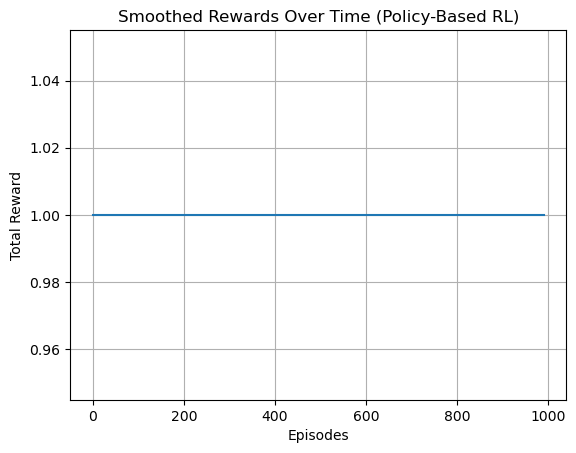

In [23]:
# STEP3: Lets run many episodes

# Train the agent
env = OneDGridEnv()
agent = PolicyAgent(state_size=5, action_size=2) # there are only 5 states (0,1,2,3,4) and 2 actions (Right,Left) 

# Print initial policy probabilities
print("\nPolicy probabilities BEFORE training:")
for s in range(agent.state_size):
    probs = agent.get_action_probs(s)
    print(f"State {s}: Left={probs[0]:.3f}, Right={probs[1]:.3f}")

EPISODES = 1000 # change to 100, 500, 1000, 7000, 15000
all_rewards = []
for episode_num in range(EPISODES):
    state = env.reset()
    episode = []
    done = False
    while not done:
        action = agent.choose_action(state)
        next_state, reward, done = env.step(action)
        episode.append((state, action, reward))
        state = next_state
        
    agent.update_policy(episode)
    total_reward = sum([r for _, _, r in episode])
    all_rewards.append(total_reward)

print(f"len(all_rewards): {len(all_rewards)}")
print("\nPolicy probabilities AFTER training:")
for s in range(agent.state_size):
    probs = agent.get_action_probs(s)
    print(f"State {s}: Left={probs[0]:.3f}, Right={probs[1]:.3f}")


# Plot reward progress
plt.plot(np.convolve(all_rewards, np.ones(10)/10, mode='valid'))
plt.title("Smoothed Rewards Over Time (Policy-Based RL)")
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.grid()
plt.show()


### observation
- Only the probability of state 3 has changed.

- Why Is the Total Reward Always 1?<br>
The only reward given is +1 when the agent reaches state 4. And the **agent always reaches state 4 in each episode (eventually)**. So: Every episode ends with a total reward of 1.

In [52]:
print(f"{'State':<6} {'P(Left)':<8} {'P(Right)':<8}")
for state in range(5):  # If you want to include the terminal state for completeness, then use all states 
    probs = agent.get_action_probs(state)
    print(f"{state:<6} {probs[0]:<8.2f} {probs[1]:<8.2f}")


State  P(Left)  P(Right)
0      0.36     0.64    
1      0.53     0.47    
2      0.50     0.50    
3      0.01     0.99    
4      0.47     0.53    


### Question: Why Are the Probabilities for “Left” High in some cases 
The Short Answer: The agent is still exploring, or it hasn't learned enough from the reward signal due to:
- Small gradients (from policy gradient update)
- Lack of penalties for bad actions (like going left)
- No negative rewards for wasting time

What's Causing This?: Let’s take a quick look at how the current learning is set up:
- Rewards are sparse (only +1 at the goal)
- Going left gives no feedback unless it delays reaching the goal
- The loss function only gets a useful signal at the end of an episode
- Policy updates use REINFORCE, which is high-variance and slow to converge

This leads to no strong pressure against going left—unless you:
- Penalize it
- Train for more episodes
- Use better reward shaping

Lets fix this by **penalizing if moving away from goal**

# PSEUDOCODE

```
1. Define the Environment:
    Class OneDGridEnv: This class represents a simple one-dimensional grid environment.
    
    Initialization (__init__):
     The agent starts at position 0 (state = 0).
     A flag (done) indicates whether the episode has ended (initially set to False).
    
    Reset Method (reset):
     Resets the agent's position to 0 and sets done to False.
     Returns the initial state (0).
    
    Step Method (step):
     Takes an action (0 for left, 1 for right).
     If the episode is already done, it raises an error.
     It saves the previous state to check if the agent is moving closer to or further from the goal.
     Updates the agent's position based on the action, ensuring it stays within the bounds (0 to 4).
     Applies a small penalty of -0.01 for each step taken.
     If the agent moves away from the goal (state 4), it incurs a larger penalty of -0.1.
     If the agent reaches the goal (state 4), it receives a reward of 1.0 and sets done to True.
     Returns the new state, the reward, and whether the episode is done.

2. Define the Policy Agent:
    Class PolicyAgent: This class represents the agent that learns to navigate the environment.
    
    Initialization (__init__):
      Takes the size of the state space and action space, and initializes a random policy.
      Sets a learning rate for updating the policy.
    
    Get Action Probabilities Method (get_action_probs):
      Computes the probabilities of taking each action based on the current state using the softmax function for numerical stability.
    
    Choose Action Method (choose_action):
      Uses the action probabilities to randomly select an action based on the current state.
    
    Update Method (update):
      Updates the agent's policy based on the state, action taken, and the return (total discounted reward) from that action.
      It calculates the gradient of the policy and adjusts the policy based on the learning rate and the return.

3. Training the Agent:
    Training Parameters:
      Sets the number of episodes for training (e.g., 1000) and a discount factor (gamma) for future rewards.
    
    Initialize Environment and Agent:
      Creates instances of the environment and the agent.
    
    Training Loop:
      For each episode:
           Resets the environment and initializes variables for tracking rewards and episode data.
           While the episode is not done:
             The agent chooses an action based on the current state.
             The environment processes the action and returns the next state, reward, and whether the episode is done.
             Records the state, action, and reward in the episode data and accumulates the total reward.
        
           After the episode ends, it calculates the discounted returns for each step in reverse order.
           Updates the agent's policy using the state, action, and calculated returns.
           Every 100 episodes, it prints the total reward and the action probabilities for each state.
```

Episode 100 | Total Reward: 0.52
State  P(Left)  P(Right)
0      0.45     0.55    
1      0.37     0.63    
2      0.41     0.59    
3      0.47     0.53    
4      0.47     0.53    

Episode 200 | Total Reward: 0.97
State  P(Left)  P(Right)
0      0.38     0.62    
1      0.29     0.71    
2      0.38     0.62    
3      0.36     0.64    
4      0.47     0.53    

Episode 300 | Total Reward: 0.85
State  P(Left)  P(Right)
0      0.39     0.61    
1      0.26     0.74    
2      0.31     0.69    
3      0.32     0.68    
4      0.47     0.53    

Episode 400 | Total Reward: 0.86
State  P(Left)  P(Right)
0      0.39     0.61    
1      0.27     0.73    
2      0.27     0.73    
3      0.27     0.73    
4      0.47     0.53    

Episode 500 | Total Reward: 0.73
State  P(Left)  P(Right)
0      0.46     0.54    
1      0.25     0.75    
2      0.24     0.76    
3      0.23     0.77    
4      0.47     0.53    

Episode 600 | Total Reward: 0.85
State  P(Left)  P(Right)
0      0.50     0.50  

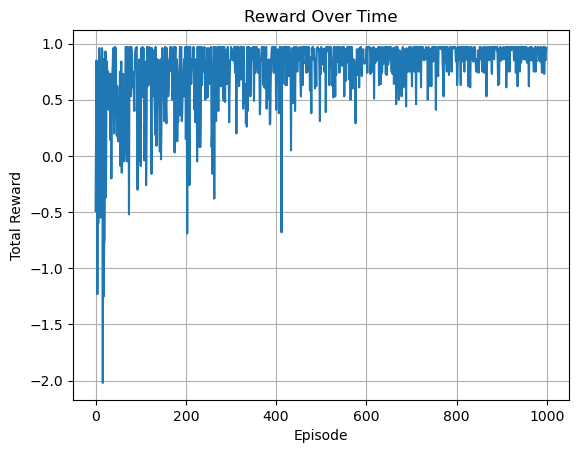

In [27]:
# Here I am using discounted reward: future rewards are considered when updating earlier states.
class OneDGridEnv:
    def __init__(self):
        self.state = 0
        self.done = False

    def reset(self):
        self.state = 0
        self.done = False
        return self.state

    def step(self, action):
        if self.done:
            raise ValueError("Episode has ended. Call reset() to start a new one.")

        prev_state = self.state

        # Action: 0 = left, 1 = right 
        if action == 1:
            self.state = min(4, self.state + 1)
        elif action == 0:
            self.state = max(0, self.state - 1)
        
        reward = -0.01 # Small step penalty

        # Penalize if moving away from goal
        if abs(self.state - 4) > abs(prev_state - 4):
            reward = -0.1

        # Reward for reaching goal
        if self.state == 4:
            reward = 1.0
            self.done = True

        return self.state, reward, self.done


class PolicyAgent:
    def __init__(self, state_size, action_size, learning_rate=0.1):
        self.state_size = state_size
        self.action_size = action_size
        self.policy = np.random.rand(state_size, action_size)
        self.learning_rate = learning_rate

    def get_action_probs(self, state):
        z = self.policy[state]
        exp = np.exp(z - np.max(z))  # for numerical stability
        return exp / np.sum(exp)

    def choose_action(self, state):
        probs = self.get_action_probs(state)
        return np.random.choice(self.action_size, p=probs)

    def update(self, state, action, Gt): # TODO
        # print("\n--- Policy Update Debug ---")
        probs = self.get_action_probs(state)
        grad = -probs
        grad[action] += 1  # ∇log(π(a|s))
        self.policy[state] += self.learning_rate * grad * Gt


# Training Parameters
# EPISODES = 1000
gamma = 0.99

# Initialize environment and agent
env = OneDGridEnv()
agent = PolicyAgent(state_size=5, action_size=2, learning_rate=0.01)

episode_rewards = []

for episode in range(EPISODES):
    state = env.reset()
    done = False
    episode_data = []
    total_reward = 0

    while not done:
        action = agent.choose_action(state)
        next_state, reward, done = env.step(action)
        episode_data.append((state, action, reward))
        total_reward += reward
        state = next_state

    episode_rewards.append(total_reward)

    # Compute discounted returns
    G = 0
    returns = []
    for _, _, reward in reversed(episode_data):
        G = reward + gamma * G
        returns.insert(0, G)

    for (state, action, _), Gt in zip(episode_data, returns):
        agent.update(state, action, Gt)

    # Show policy every 100 episodes
    if (episode + 1) % 100 == 0:
        print(f"Episode {episode + 1} | Total Reward: {total_reward:.2f}")
        print(f"{'State':<6} {'P(Left)':<8} {'P(Right)':<8}")
        for s in range(5):
            probs = agent.get_action_probs(s)
            print(f"{s:<6} {probs[0]:<8.2f} {probs[1]:<8.2f}")
        print()

# Plot total reward
plt.plot(episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Reward Over Time")
plt.grid(True)
plt.show()


## Observation

- Here if we increase the number of episodes to more than 1000, then P(Left) when in state 0,1,2,3 would become 0 and P(Right) when in state 0,1,2,3 would become 1.

The ***optimal policy*** is:<br>
At every state (positions 0 to 3), take action 1 → move right.<br>
**State 4 is terminal state. Although its showing a probability, it can be ignored or just change the range(5) -> range(4)**<br>
The agent should never move left. Doing so wastes steps and delays reaching the reward.